# День 08. Упражнение 03
# Переобучение

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
from sklearn.model_selection import cross_val_score
import joblib

## 1. Предобработка

1. Прочитай файл `dayofweek.csv` в DataFrame.
2. Используя `train_test_split` с параметрами `test_size=0.2`, `random_state=21`, получи `X_train`, `y_train`, `X_test`, `y_test`.
3. С помощью, например, `value_counts()` проверь, похожее ли распределение классов в train и test.
4. Добавь параметр `stratify=` и проверь распределение снова — теперь оно должно быть более-менее одинаковым в обоих наборах данных.

In [2]:
df = pd.read_csv('../data/dayofweek.csv')
df.head()

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
X = df.drop(columns=['dayofweek'])
y = df['dayofweek']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21
)

In [4]:
print('===Распределение классов в обучающей выборке===')
y_train.value_counts()

===Распределение классов в обучающей выборке===


dayofweek
3    313
6    287
1    222
5    216
2    125
0    105
4     80
Name: count, dtype: int64

In [5]:
print('===Распределение классов в тестовой выборке===')
y_test.value_counts()

===Распределение классов в тестовой выборке===


dayofweek
3    83
6    69
5    55
1    52
0    31
4    24
2    24
Name: count, dtype: int64

Соотношение классов в выборках не совпадает: в обучающей самый ненасыщенный класс - 4, в тестовой - 2

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

In [7]:
print('===Распределение классов в обучающей выборке===')
y_train.value_counts()

===Распределение классов в обучающей выборке===


dayofweek
3    316
6    285
1    219
5    217
2    119
0    109
4     83
Name: count, dtype: int64

In [8]:
print('===Распределение классов в тестовой выборке===')
y_test.value_counts()

===Распределение классов в тестовой выборке===


dayofweek
3    80
6    71
1    55
5    54
2    30
0    27
4    21
Name: count, dtype: int64

Соотношение классов стало одинаковым

## 2. Базовые модели

1. Обучи те же самые базовые модели из предыдущего упражнения и вычисли accuracy, используя тестовый набор данных со стратификацией.
2. Все ли модели показали похожие значения метрики? Какая из них показала наибольшее отличие по сравнению с предыдущим упражнением? Напиши ответ в markdown-ячейке в конце раздела.

### a. Логистическая регрессия

In [9]:
model_logreg = OneVsRestClassifier(
    LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')
)
model_logreg.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](43,)","['numTrials','hour','uid_user_0',...,'labname_laba06','labname_laba06s', 'labname_project1']"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,43


In [10]:
predict_logreg = model_logreg.predict(X_test)
print(f'Accuracy для лог регрессии: {accuracy_score(y_test, predict_logreg)}')

Accuracy для лог регрессии: 0.6153846153846154


### b. SVM

In [11]:
warnings.filterwarnings('ignore')

model_svc = OneVsRestClassifier(
    SVC(kernel='linear', probability=True, random_state=21)
)
model_svc.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(kernel='l...ndom_state=21)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[SVC(kernel='l...ndom_state=21), SVC(kernel='l...ndom_state=21), SVC(kernel='l...ndom_state=21), SVC(kernel='l...ndom_state=21), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](43,)","['numTrials','hour','uid_user_0',...,'labname_laba06','labname_laba06s', 'labname_project1']"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,43


In [12]:
predict_svc = model_svc.predict(X_test)
print(f'Accuracy для метода опорных векторов: {accuracy_score(y_test, predict_svc)}')

Accuracy для метода опорных векторов: 0.6183431952662722


### c. Дерево решений

In [13]:
model_tree = DecisionTreeClassifier(max_depth=4, random_state=21)
model_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",21
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [14]:
predict_tree = model_tree.predict(X_test)
print(f'Accuracy для дерева решений: {accuracy_score(y_test, predict_tree)}')

Accuracy для дерева решений: 0.5295857988165681


### d. Случайный лес

In [15]:
model_random_forest = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model_random_forest.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",21
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [16]:
predict_random_forest = model_random_forest.predict(X_test)
print(f'Accuracy для случайного леса: {accuracy_score(y_test, predict_random_forest)}')

Accuracy для случайного леса: 0.9289940828402367


## Выводы

|Модель|Accuracy|
|-|-|
|Логистическая регрессия|0.6153846153846154|
|Метод опорных векторов|0.6183431952662722|
|Дерево решений|0.5295857988165681|
|Случайный лес|0.9289940828402367|

Логистическая регрессия и метод опорных векторов дали примерно одинаковый результат, хуже всего справилось дерево решений, а лучший результат показал **случайный лес**

## 3. Кросс-валидация

Можно было бы “поиграть” с параметрами модели, чтобы добиться более высокой точности на тестовом наборе, но так делать не принято. Такая тактика снова приводит к переобучению. Тестовый набор предназначен только для финальной проверки качества модели.

Однако есть другой способ решения этой задачи — кросс-валидация. Он не использует тестовый набор, а создает дополнительное разбиение обучающего набора. Существует несколько способов реализации, но общая идея одна: появляется валидационный набор, который используется для подбора гиперпараметров.

1. Используя `cross_val_score` с параметром `cv=10`, вычисли среднее значение accuracy и стандартное отклонение для каждой модели, использованной ранее (логистическая регрессия с `solver='liblinear'`, SVC, дерево решений, случайный лес).

### a. Логистическая регрессия

In [17]:
scores_logreg = cross_val_score(model_logreg, X_train, y_train, cv=10)
print('===Логистическая регрессия===')
print(f'Средняя accuracy: {scores_logreg.mean()}')
print(f'Среднее std: {scores_logreg.std()}')

===Логистическая регрессия===
Средняя accuracy: 0.5815975677169707
Среднее std: 0.025322132907253592


### b. SVM

In [18]:
scores_svc = cross_val_score(model_svc, X_train, y_train, cv=10)
print('===Метод опорных векторов===')
print(f'Средняя accuracy: {scores_svc.mean()}')
print(f'Среднее std: {scores_svc.std()}')

===Метод опорных векторов===
Средняя accuracy: 0.5705085682697624
Среднее std: 0.037010421284044116


### c. Дерево решений

In [19]:
scores_tree = cross_val_score(model_tree, X_train, y_train, cv=10)
print('===Дерево решений===')
print(f'Средняя accuracy: {scores_tree.mean()}')
print(f'Среднее std: {scores_tree.std()}')

===Дерево решений===
Средняя accuracy: 0.5088944168048645
Среднее std: 0.031903139495514356


### d. Случайный лес

In [20]:
scores_random_forest = cross_val_score(model_random_forest, X_train, y_train, cv=10)
print('===Случайный лес===')
print(f'Средняя accuracy: {scores_random_forest.mean()}')
print(f'Среднее std: {scores_random_forest.std()}')

===Случайный лес===
Средняя accuracy: 0.9176561636263129
Среднее std: 0.02159583796321821


## 4. Оптимизация

1. Выбери лучшую модель и немного поиграй с её параметрами на кросс-валидации, чтобы найти достаточно хорошие параметры или их комбинацию.
2. Вычисли accuracy для финальной модели на тестовом наборе данных.
3. Построй график, отображающий 10 самых важных признаков для этой модели.
4. Сохрани модель с помощью `joblib`.
5. Загрузи модель, сделай предсказания для тестового набора и вычисли accuracy.

In [21]:
param_grid = {
    'n_estimators': range(100, 301, 100),
    'max_depth': [25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 3],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=21),
    param_grid=param_grid,
    cv=10,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 81 candidates, totalling 810 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=21)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [25, 30, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': range(100, 301, 100)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sph

In [22]:
print(f'Лучшие параметры: {grid_search.best_params_}')
print(f'Лучшая accuracy: {grid_search.best_score_}')

Лучшие параметры: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Лучшая accuracy: 0.9176561636263129


In [23]:
model_best = grid_search.best_estimator_
predict_best = model_best.predict(X_test)
print(f'Accuracy для лучшей модели на тесте: {accuracy_score(y_test, predict_best)}')

Accuracy для лучшей модели на тесте: 0.9289940828402367


In [24]:
def draw_feature_importance(model, feature_names, top_n=10):
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    else:
        raise ValueError('Модель не поддерживается')

    top_idx = np.argsort(importance)[-top_n:][::-1]

    df_plot = pd.DataFrame({
        'feature': np.array(feature_names)[top_idx],
        'importance': importance[top_idx]
    })

    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(data=df_plot, x='importance', y='feature', color='thistle', ax=ax)
    ax.set_title(f'Топ-{top_n} важных признаков')
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

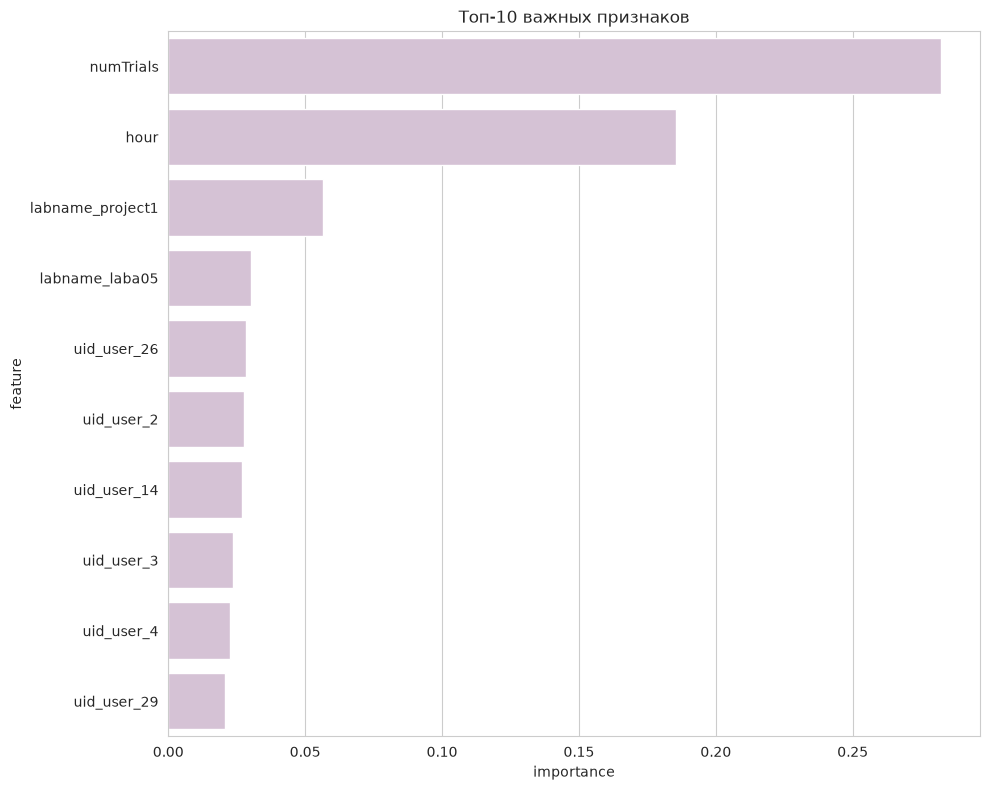

In [25]:
draw_feature_importance(model_best, X.columns)

In [26]:
joblib.dump(model_best, '../data/model_best.pkl')

['../data/model_best.pkl']

In [27]:
model = joblib.load('../data/model_best.pkl')
predict = model.predict(X_test)
print(f'Accuracy загруженной модели на тесте: {accuracy_score(y_test, predict_best)}')

Accuracy загруженной модели на тесте: 0.9289940828402367
